# Stock News Sentiment → Next Day Return Prediction

End-to-end pipeline:
1. **Ingest** — pull headlines from GDELT BigQuery
2. **Score** — run FinBERT, VADER, V2Tone, and Gemma (via LM Studio)
3. **Engineer** — compute daily sentiment features (shock, momentum, volume, etc.)
4. **Merge** — join with yfinance price data + VIX
5. **Train** — XGBoost grid search with chronological train/val/test split
6. **Evaluate** — validation & holdout diagnostics, trading simulation
7. **Backup / Restore** — snapshot all artefacts to disk

---
## 0 · Configuration

All user-tunable settings live here. No need to edit any other cell.

In [ ]:
# ── Target stock ──────────────────────────────────────────────────────────────
TICKER       = "NVDA"
COMPANY_NAME = "NVIDIA"
KEYWORDS     = ["NVIDIA", "NVDA"]   # used for GDELT regex and headline filtering

# ── Date range ────────────────────────────────────────────────────────────────
DATE_FROM = "2026-04-12"
DATE_TO   = "2026-04-15"

# ── Sentiment model toggles ───────────────────────────────────────────────────
RUN_FINBERT = True
RUN_VADER   = True
RUN_V2TONE  = True
RUN_GEMMA   = True

# ── Ollama / LLM ─────────────────────────────────────────────────────────────
OLLAMA_BASE_URL = "http://127.0.0.1:11434"

# Add, remove, or swap any Ollama-compatible model.
# Format: (name, ollama_model_id)
# "name" becomes the score column prefix, e.g. "gemma3" -> "gemma3_score"
LLM_MODELS = [
    ("gemma3", "gemma3:4b"),
    ("gemma4", "gemma4:e4b"),
    # ("llama3",  "llama3.1:8b"),
    # ("mistral", "mistral:7b"),
    # ("phi3",    "phi3:mini"),
    # ("qwen",    "qwen2.5:7b"),
]
# ── BigQuery ──────────────────────────────────────────────────────────────────
GCP_CREDENTIALS_PATH = r"C:\Users\JG\Documents\PythonProjects\StockNewsML\stocknews-492206-ffa852168d59.json"
GCP_PROJECT_ID       = "stocknews-492206"

# ── Fetch / checkpoint settings ───────────────────────────────────────────────
FETCH_DELAY_SECONDS = 0.5    # polite pause between BigQuery calls
LLM_MAX_RETRIES   = 3
LLM_RETRY_DELAY   = 2      # seconds between retries
LLM_POLL_INTERVAL = 15     # seconds between model-detection polls
LLM_CHUNK_SIZE    = 500     # number of articles sent per LLM API call
LLM_WORKERS       = 5      # parallel LLM calls (set to CPU cores or less)

# ── Price / feature engineering ───────────────────────────────────────────────
TARGET_HORIZON_DAYS = 2      # n-day forward return for binary target
LOOKBACK_DAYS       = 80     # warm-up days downloaded before DATE_FROM (needs ~55 trading days for ma_50)
ROLLING_WINDOW      = 30     # long-term sentiment baseline window
NEUTRAL_MULTIPLIER  = 0.02   # near-neutral article filter (× rolling std)

# ── Train / val / test split ──────────────────────────────────────────────────
VALIDATION_SPLIT = 0.20      # fraction of pre-test data held for validation

# ── XGBoost grid search ───────────────────────────────────────────────────────
XGB_FEATURES = [
    "avg_score", "momentum", "std", "shock", "volume", "surprise_10", "accel",
]
TARGET_COL          = "target"
DECISION_THRESHOLD  = 0.5    # set to "X" to enable auto-threshold search
THRESHOLD_DEAD_ZONE = (0.0, 0.0)  # predictions in (low, high) are abstained
SELECTION_METRIC    = "precision"  # accuracy | precision | recall | f1 | roc_auc
SCALE_POS_WEIGHT    = False  # True → compensate for class imbalance

XGB_PARAM_GRID = {
    "n_estimators":      [100, 150],
    "max_depth":         [2, 3, 4],
    "min_child_weight":  [3, 5, 7],
    "learning_rate":     [0.01, 0.03, 0.05],
    "subsample":         [0.5, 0.7],
    "colsample_bytree":  [0.5, 0.6],
    "colsample_bylevel": [0.5, 0.7],
    "gamma":             [0.3, 1.0],
    "reg_alpha":         [0.4, 2.0],
    "reg_lambda":        [4, 10],
}

# ── Trading simulation ────────────────────────────────────────────────────────
LONG_THRESHOLD  = 0.55
SHORT_THRESHOLD = 0.45

# ── Paths ─────────────────────────────────────────────────────────────────────
SESSION_LOG_DIR = r"D:\PRODStockNews\session_logs"   # checkpoints, parquets, frozen models
BACKUP_ROOT     = r"D:\PRODStockNews\backup"

# ── Derived (do not edit) ─────────────────────────────────────────────────────
from datetime import datetime, timedelta
import re

SQL_PATTERN = f"(?i){'|'.join(KEYWORDS)}"
_start = datetime.strptime(DATE_FROM, "%Y-%m-%d")
_end   = datetime.strptime(DATE_TO,   "%Y-%m-%d")
TEST_CUTOFF_DATE = (
    _start + timedelta(seconds=(_end - _start).total_seconds() * 0.8)
).strftime("%Y-%m-%d")
KEYWORDS_RE = re.compile(f"({'|'.join(KEYWORDS)})", re.IGNORECASE)

print(f"Ticker            : {TICKER}")
print(f"Date range        : {DATE_FROM} → {DATE_TO}")
print(f"Train/test cutoff : {TEST_CUTOFF_DATE}")
print(f"SQL regex pattern : {SQL_PATTERN}")
print(f"Session log dir   : {SESSION_LOG_DIR}")

Ticker            : NVDA
Date range        : 2026-04-12 → 2026-04-15
Train/test cutoff : 2026-04-14
SQL regex pattern : (?i)NVIDIA|NVDA
Session log dir   : D:\PRODStockNews\session_logs


---
## 1 · Imports

In [81]:
import html
import os
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import requests
import seaborn as sns
import torch
import yfinance as yf
from google.cloud import bigquery
from sklearn.metrics import (
    accuracy_score, auc, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score, roc_curve,
)
from sklearn.model_selection import ParameterGrid
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from xgboost import XGBClassifier

tqdm.pandas()
print("Imports OK")

Imports OK


---
## 2 · GDELT Ingest

Fetches headline data from `gdelt-bq.gdeltv2.gkg_partitioned` with per-day
checkpointing so long runs are resumable after a crash.

In [82]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = GCP_CREDENTIALS_PATH
bq_client = bigquery.Client(project=GCP_PROJECT_ID)
os.makedirs(SESSION_LOG_DIR, exist_ok=True)


def _fetch_day(target_date: date, sql_pattern: str) -> pd.DataFrame:
    """Run a single-day BigQuery partition scan and return a DataFrame."""
    date_str = target_date.strftime("%Y-%m-%d")
    query = f"""
        SELECT
            _PARTITIONDATE AS date,
            REGEXP_EXTRACT(Extras, r'<PAGE_TITLE>(.*?)</PAGE_TITLE>') AS headline,
            CAST(SPLIT(V2Tone, ',')[OFFSET(0)] AS FLOAT64) AS V2Tone,
            DocumentIdentifier AS url
        FROM `gdelt-bq.gdeltv2.gkg_partitioned`
        WHERE
            _PARTITIONDATE = '{date_str}'
            AND REGEXP_CONTAINS(
                REGEXP_EXTRACT(Extras, r'<PAGE_TITLE>(.*?)</PAGE_TITLE>'),
                r'{sql_pattern}'
            )
            AND REGEXP_EXTRACT(Extras, r'<PAGE_TITLE>(.*?)</PAGE_TITLE>') IS NOT NULL
    """
    return bq_client.query(query).to_dataframe()


def fetch_articles(
    date_from: str,
    date_to: str,
    sql_pattern: str,
    ticker: str = TICKER,
    delay: float = FETCH_DELAY_SECONDS,
    checkpoint_dir: str | None = None,
    resume_from: str | None = None,
) -> pd.DataFrame:
    """
    Fetch GDELT articles across a date range.

    Args:
        date_from, date_to : ISO date strings (inclusive).
        sql_pattern        : BigQuery REGEXP_CONTAINS pattern.
        ticker             : Used to name checkpoint files.
        delay              : Seconds to sleep between requests.
        checkpoint_dir     : If set, save one parquet per day for crash recovery.
                             Defaults to SESSION_LOG_DIR/checkpoints_{ticker}.
        resume_from        : Skip days before this ISO date.

    Returns:
        Combined DataFrame with columns [date, headline, V2Tone, url].
    """
    if checkpoint_dir is None:
        checkpoint_dir = os.path.join(SESSION_LOG_DIR, f"checkpoints_{ticker}")
    os.makedirs(checkpoint_dir, exist_ok=True)

    start = date.fromisoformat(date_from)
    end   = date.fromisoformat(date_to)
    total_days   = (end - start).days + 1
    resume_date  = date.fromisoformat(resume_from) if resume_from else start

    all_frames, failed_dates = [], []
    current = start

    print(f"Ticker     : {ticker}")
    print(f"Date range : {date_from} → {date_to} ({total_days} days)")
    if resume_from:
        print(f"Resuming from {resume_from}")

    while current <= end:
        day_num   = (current - start).days + 1
        date_str  = current.strftime("%Y-%m-%d")
        ckpt_path = os.path.join(checkpoint_dir, f"{ticker}_{date_str}.parquet")

        if os.path.exists(ckpt_path):
            df = pd.read_parquet(ckpt_path)
            all_frames.append(df)
            print(f"  [{day_num:>4}/{total_days}] {date_str}  (cached) → {len(df)} rows")
            current += timedelta(days=1)
            continue

        if current < resume_date:
            print(f"  [{day_num:>4}/{total_days}] {date_str}  (skipped)")
            current += timedelta(days=1)
            continue

        print(f"  [{day_num:>4}/{total_days}] {date_str}", end="", flush=True)
        try:
            df = _fetch_day(current, sql_pattern)
            df = df.drop_duplicates(subset=["headline", "date"])
            df.to_parquet(ckpt_path, index=False)
            all_frames.append(df)
            print(f"  → {len(df):>4} rows")
        except Exception as exc:
            failed_dates.append(date_str)
            print(f"  → FAILED: {exc}")

        current += timedelta(days=1)
        if current <= end:
            time.sleep(delay)

    if not all_frames:
        print("\nNo articles found in range.")
        return pd.DataFrame(columns=["date", "headline", "V2Tone", "url"])

    combined = (
        pd.concat(all_frames, ignore_index=True)
        .drop_duplicates(subset=["headline", "date"])
        .sort_values("date")
        .reset_index(drop=True)
    )
    print(f"\n{'─'*50}")
    print(f"Total rows   : {len(combined)}")
    print(f"Days fetched : {total_days - len(failed_dates)}/{total_days}")
    if failed_dates:
        print(f"Failed dates : {', '.join(failed_dates)}")
        print("  → Re-run with resume_from='<first failed date>' to retry")
    return combined


# ── Run ───────────────────────────────────────────────────────────────────────
df = fetch_articles(
    DATE_FROM, DATE_TO, SQL_PATTERN,
    # resume_from="2024-06-15",  # uncomment to resume after a crash
)

Ticker     : NVDA
Date range : 2026-04-12 → 2026-04-15 (4 days)
  [   1/4] 2026-04-12  →   37 rows
  [   2/4] 2026-04-13  →   77 rows
  [   3/4] 2026-04-14  →  169 rows
  [   4/4] 2026-04-15  →  138 rows

──────────────────────────────────────────────────
Total rows   : 421
Days fetched : 4/4


---
## 3 · Headline Cleaning

In [83]:
def clean_headline(text: str | None) -> str | None:
    """
    Clean and validate a single headline string.

    Returns the cleaned text, or None if the headline should be discarded
    (missing keyword, non-ASCII characters, or empty after cleaning).
    """
    if not text or pd.isna(text):
        return None

    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", "", text)   # strip residual HTML tags
    text = " ".join(text.split())          # normalise whitespace

    if not KEYWORDS_RE.search(text):
        return None

    if not all(ord(c) < 128 for c in text):
        return None

    return text.strip() or None


def clean_dataframe(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Apply cleaning, deduplication, and return the filtered DataFrame."""
    df_clean = df_raw.copy()
    df_clean["headline"] = df_clean["headline"].apply(clean_headline)
    df_clean = df_clean.dropna(subset=["headline"])

    # Deduplicate on a 30-char headline prefix (catches near-identical titles)
    df_clean["_prefix"] = df_clean["headline"].str[:30]
    df_clean = df_clean.drop_duplicates(subset="_prefix").drop(columns="_prefix")

    return df_clean.reset_index(drop=True)


df = clean_dataframe(df)

articles_per_day = (
    df.dropna(subset=["date"])
    .assign(date=pd.to_datetime(df["date"]).dt.normalize())
    .groupby("date", as_index=False)
    .size()
    .rename(columns={"size": "article_count"})
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Headlines after cleaning : {len(df):,}")
print(f"Days with coverage       : {len(articles_per_day)}")
display(articles_per_day.head())

Headlines after cleaning : 210
Days with coverage       : 4


,date,article_count
0,2026-04-12,21
1,2026-04-13,38
2,2026-04-14,77
3,2026-04-15,74


---
## 4 · Sentiment Scoring

Four scorers run in sequence:
- **Gemma 3 & 4 by default** (via Ollama, chunked + checkpointed)
- **FinBERT** (HuggingFace)
- **VADER**
- **V2Tone** (GDELT built-in)

In [84]:
# ── Ollama helpers ────────────────────────────────────────────────────────────

def _ollama_is_running(base_url: str = OLLAMA_BASE_URL) -> bool:
    """Return True if Ollama is reachable."""
    try:
        r = requests.get(f"{base_url}/api/tags", timeout=5)
        return r.ok
    except Exception:
        return False


def ensure_model(model_id: str, poll_interval: int = LLM_POLL_INTERVAL) -> None:
    """Block until Ollama is up and model_id is available locally; pulls if needed."""
    print(f"\n{'='*55}")
    print(f"  Model      : {model_id}")
    print(f"  Ollama URL : {OLLAMA_BASE_URL}")
    print(f"{'='*55}")
    while not _ollama_is_running():
        print(f"  Ollama not reachable - retrying in {poll_interval}s ...")
        time.sleep(poll_interval)
    try:
        r = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=10)
        pulled = [m["name"] for m in r.json().get("models", [])]
        if not any(model_id.lower() in p.lower() for p in pulled):
            print(f"  Pulling '{model_id}' (this may take a while) ...")
            requests.post(f"{OLLAMA_BASE_URL}/api/pull", json={"name": model_id}, timeout=600)
            print("  Pull complete.")
    except Exception as e:
        print(f"  Warning: could not verify model list - {e}")
    print(f"  Ready: '{model_id}'\n")


def _build_llm_prompt(headline: str) -> str:
    text = "" if pd.isna(headline) else str(headline).strip()
    return (
        f'Does this statement reflect positively, negatively, or neutrally '
        f'on the stock price of {COMPANY_NAME}?\n\n"{text}"\n\n'
        "Return only one number between -1 and 1."
    )


def _parse_llm_response(text: str) -> float:
    value = re.sub(r"<think>.*?</think>", "", text or "", flags=re.IGNORECASE | re.DOTALL).strip()
    match = re.search(r"-?\d*\.?\d+", value)
    if not match:
        return 0.0
    score = float(match.group())
    return score if -1 <= score <= 1 else 0.0


def _score_one(headline: str, model_id: str, timeout: int = 60) -> float:
    """Score a single headline via Ollama with retries."""
    for attempt in range(LLM_MAX_RETRIES):
        try:
            r = requests.post(
                f"{OLLAMA_BASE_URL}/api/chat",
                json={
                    "model": model_id,
                    "messages": [{"role": "user", "content": _build_llm_prompt(headline)}],
                    "stream": False,
                    "options": {
                        "temperature": 0.2,
                        "top_p":       0.95,
                        "num_predict": 16,
                        "stop":        ["\n"],
                    },
                },
                timeout=timeout,
            )
            r.raise_for_status()
            return _parse_llm_response(r.json()["message"]["content"])
        except Exception:
            if attempt < LLM_MAX_RETRIES - 1:
                time.sleep(LLM_RETRY_DELAY)
    return 0.0


def run_llm_chunked(
    df_input: pd.DataFrame,
    model_id: str,
    out_col: str,
    chunk_size: int = LLM_CHUNK_SIZE,
    workers: int = LLM_WORKERS,
    checkpoint_path: str | None = None,
) -> pd.DataFrame:
    """Score headlines in parallel chunks with parquet checkpointing."""
    if checkpoint_path is None:
        checkpoint_path = f"checkpoint_{out_col}.parquet"

    if os.path.exists(checkpoint_path):
        done = pd.read_parquet(checkpoint_path)
        remaining = df_input[~df_input.index.isin(set(done.index))]
        results = [done]
        print(f"Resuming: {len(done):,} done, {len(remaining):,} remaining")
    else:
        remaining = df_input.copy()
        results = []

    if remaining.empty:
        print("All rows already scored.")
        return pd.concat(results).sort_index() if results else df_input.copy().assign(**{out_col: []})

    chunks = [remaining.iloc[i:i + chunk_size] for i in range(0, len(remaining), chunk_size)]
    print(f"Scoring {len(remaining):,} rows in {len(chunks)} chunks of {chunk_size} using '{model_id}'")

    for idx, chunk in enumerate(chunks):
        headlines = chunk["headline"].tolist()
        scores = [None] * len(headlines)
        with ThreadPoolExecutor(max_workers=workers) as executor:
            futures = {executor.submit(_score_one, h, model_id): i for i, h in enumerate(headlines)}
            with tqdm(total=len(headlines), desc=f"Chunk {idx + 1}/{len(chunks)}") as pbar:
                for future in as_completed(futures):
                    scores[futures[future]] = future.result()
                    pbar.update(1)
        chunk = chunk.copy()
        chunk[out_col] = scores
        results.append(chunk)
        pd.concat(results).to_parquet(checkpoint_path)
        print(f"  Chunk {idx + 1}/{len(chunks)} saved - {sum(len(r) for r in results):,} total")

    final = pd.concat(results).sort_index()
    if os.path.exists(checkpoint_path):
        os.remove(checkpoint_path)
    return final


# ── FinBERT helpers ───────────────────────────────────────────────────────────

if RUN_FINBERT:
    print("Loading FinBERT...")
    _finbert_tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
    _finbert_model     = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
    print("FinBERT ready.")


def score_finbert(text: str) -> str:
    """Return 'positive', 'neutral', or 'negative'."""
    text = "" if pd.isna(text) else str(text)
    inputs = _finbert_tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = _finbert_model(**inputs)
    idx = torch.argmax(outputs.logits, dim=1).item()
    return ["negative", "neutral", "positive"][idx]


_FINBERT_MAP = {"negative": -1, "neutral": 0, "positive": 1}


# ── VADER helper ──────────────────────────────────────────────────────────────

if RUN_VADER:
    _vader = SentimentIntensityAnalyzer()


def score_vader(text: str) -> float:
    """Return VADER compound score in [-1, 1]."""
    return _vader.polarity_scores("" if pd.isna(text) else str(text))["compound"]


# ── V2Tone helper ─────────────────────────────────────────────────────────────

def parse_v2tone(tone_str) -> float | None:
    """Extract the first tone value and normalise to [-1, 1]."""
    try:
        return float(str(tone_str).split(",")[0]) / 10
    except Exception:
        return None


Loading FinBERT...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 25860.59it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT ready.


In [85]:
# ── Run all scorers ───────────────────────────────────────────────────────────

working = df[["date", "headline", "V2Tone"]].copy().dropna(subset=["headline"])

# LLM models via Ollama — any model listed in LLM_MODELS
if RUN_GEMMA:
    for name, model_id in LLM_MODELS:
        out_col = f"{name}_score"
        ensure_model(model_id)
        working = run_llm_chunked(working, model_id=model_id, out_col=out_col)
        print(f"{name} complete - '{out_col}' added.")

    # Use the last model's score as the primary 'gemma_score' alias
    last_name = LLM_MODELS[-1][0] if LLM_MODELS else None
    if last_name and f"{last_name}_score" in working.columns:
        working["gemma_score"] = working[f"{last_name}_score"]
    else:
        working["gemma_score"] = 0.0

# FinBERT
if RUN_FINBERT:
    print("Running FinBERT...")
    working["finbert_label"] = working["headline"].progress_apply(score_finbert)
    working["finbert_score"] = working["finbert_label"].map(_FINBERT_MAP)
    print("FinBERT done.")
else:
    working["finbert_score"] = 0.0

# VADER
if RUN_VADER:
    print("Running VADER...")
    working["vader_score"] = working["headline"].progress_apply(score_vader)
    print("VADER done.")
else:
    working["vader_score"] = 0.0

# V2Tone
if RUN_V2TONE:
    print("Running V2Tone...")
    working["v2tone_score"] = working["V2Tone"].progress_apply(parse_v2tone)
    print("V2Tone done.")
else:
    working["v2tone_score"] = 0.0

# Assemble final sentiment DataFrame
_gemma_cols = [f"{name}_score" for name, _ in LLM_MODELS if f"{name}_score" in working.columns]
if "gemma_score" in working.columns and "gemma_score" not in _gemma_cols:
    _gemma_cols = ["gemma_score"] + _gemma_cols
df_sentiments = working[
    ["date", "headline", "v2tone_score", "vader_score", "finbert_score"] + _gemma_cols
].reset_index(drop=True)

df_sentiments.to_parquet("df_sentiments_final.parquet", index=False)

print(f"\n{'='*55}")
print(f"Pipeline complete — {len(df_sentiments):,} rows")
print(f"Columns : {df_sentiments.columns.tolist()}")
print(f"Saved to: {os.path.abspath('df_sentiments_final.parquet')}")
print(f"{'='*55}")


  Model      : gemma3:4b
  Ollama URL : http://127.0.0.1:11434
  Ready: 'gemma3:4b'

Scoring 210 rows in 1 chunks of 500 using 'gemma3:4b'


Chunk 1/1: 100%|██████████| 210/210 [00:34<00:00,  6.05it/s]


  Chunk 1/1 saved - 210 total
gemma3 complete - 'gemma3_score' added.

  Model      : gemma4:e4b
  Ollama URL : http://127.0.0.1:11434
  Ready: 'gemma4:e4b'

Scoring 210 rows in 1 chunks of 500 using 'gemma4:e4b'


Chunk 1/1: 100%|██████████| 210/210 [01:28<00:00,  2.38it/s]


  Chunk 1/1 saved - 210 total
gemma4 complete - 'gemma4_score' added.
Running FinBERT...


...

FinBERT done.
Running VADER...


100%|██████████| 210/210 [00:00<00:00, 9637.33it/s]


VADER done.
Running V2Tone...


100%|██████████| 210/210 [00:00<00:00, 105371.92it/s]


V2Tone done.

Pipeline complete — 210 rows
Columns : ['date', 'headline', 'v2tone_score', 'vader_score', 'finbert_score', 'gemma_score', 'gemma3_score', 'gemma4_score']
Saved to: d:\PRODStockNews\df_sentiments_final.parquet


---
## 5 · Feature Engineering

For each sentiment model, compute daily aggregates and derived features:
shock, momentum, volume, surprise, acceleration, extreme flag, sign flip,
and a cross-model disagreement signal.

In [86]:
# ── Optional: reload from disk ────────────────────────────────────────────────
# df_sentiments = pd.read_parquet("df_sentiments_final.parquet")
# df_sentiments["date"] = pd.to_datetime(df_sentiments["date"], errors="coerce")


def filter_near_neutral(df: pd.DataFrame, models: list[str], multiplier: float = NEUTRAL_MULTIPLIER) -> pd.DataFrame:
    """Drop articles whose score is within *multiplier* × rolling std of zero."""
    df = df.copy()
    for model in models:
        col = f"{model}_score"
        if col not in df.columns:
            continue
        threshold = multiplier * df[col].rolling(30, min_periods=1).std()
        df = df[(df[col] > threshold) | (df[col] < -threshold)]
    return df


def build_daily_features(df: pd.DataFrame, models: list[str], rolling_window: int = ROLLING_WINDOW) -> pd.DataFrame:
    """
    Aggregate article-level sentiment to daily features for each model.

    Features per model:
        {m}_avg, {m}_std, {m}_count,
        {m}_long_term, {m}_shock,
        {m}_volume,
        {m}_5d_avg,  {m}_momentum,
        {m}_10d_avg, {m}_momentum_10,
        {m}_surprise_5, {m}_surprise_10,
        {m}_accel, {m}_extreme, {m}_flip

    Plus cross-model: model_disagreement.
    """
    score_cols = {m: f"{m}_score" for m in models if f"{m}_score" in df.columns}

    agg_kwargs = {}
    for prefix, col in score_cols.items():
        agg_kwargs[f"{prefix}_avg"]   = (col, "mean")
        agg_kwargs[f"{prefix}_std"]   = (col, "std")
        agg_kwargs[f"{prefix}_count"] = (col, "count")

    out = df.groupby("date", as_index=False).agg(**agg_kwargs)

    std_cols = [f"{m}_std" for m in score_cols]
    out[std_cols] = out[std_cols].fillna(0.0)

    for m in score_cols:
        avg = f"{m}_avg"
        std = f"{m}_std"

        out[f"{m}_long_term"]   = out[avg].rolling(rolling_window, min_periods=1).mean()
        out[f"{m}_shock"]       = np.where(out[std] != 0, (out[avg] - out[f"{m}_long_term"]) / out[std], 0.0)
        out[f"{m}_volume"]      = out[avg] * np.sqrt(out[f"{m}_count"])
        out[f"{m}_5d_avg"]      = out[avg].rolling(5, min_periods=1).mean()
        out[f"{m}_momentum"]    = out[avg] - out[f"{m}_5d_avg"]
        out[f"{m}_10d_avg"]     = out[avg].rolling(10, min_periods=1).mean()
        out[f"{m}_momentum_10"] = out[avg] - out[f"{m}_10d_avg"]
        out[f"{m}_surprise_5"]  = out[avg] - out[f"{m}_5d_avg"]
        out[f"{m}_surprise_10"] = out[avg] - out[f"{m}_10d_avg"]
        out[f"{m}_accel"]       = out[avg].diff().diff()
        out[f"{m}_extreme"]     = (out[avg].abs() > 0.5).astype(int)
        out[f"{m}_flip"]        = ((out[avg] > 0) != (out[avg].shift(1) > 0)).astype(int)

    out["model_disagreement"] = out[[f"{m}_avg" for m in score_cols]].std(axis=1)

    # Fill NaN from diff/rolling at series start
    fill_cols = [f"{m}{s}" for m in score_cols for s in ("_accel", "_surprise_5", "_surprise_10")]
    out[fill_cols] = out[fill_cols].fillna(0.0)

    return out


SENTIMENT_MODELS = ["bert", "vader", "gemma3", "gemma4", "tone"]

# Rename finbert/v2tone columns to match model prefixes expected downstream
_renames = {"finbert_score": "bert_score", "v2tone_score": "tone_score"}
df_sentiments = df_sentiments.rename(columns={k: v for k, v in _renames.items() if k in df_sentiments.columns})
df_sentiments["date"] = pd.to_datetime(df_sentiments["date"])

df_sentiments = filter_near_neutral(df_sentiments, models=["vader", "tone"])
df_avg_sentiment = build_daily_features(df_sentiments, models=SENTIMENT_MODELS)

print(f"Daily feature rows : {len(df_avg_sentiment)}")
print(f"Total columns      : {len(df_avg_sentiment.columns)}")
display(df_avg_sentiment.head())

Daily feature rows : 4
Total columns      : 77


,date,bert_avg,bert_std,bert_count,vader_avg,vader_std,vader_count,gemma3_avg,gemma3_std,gemma3_count,...,tone_5d_avg,tone_momentum,tone_10d_avg,tone_momentum_10,tone_surprise_5,tone_surprise_10,tone_accel,tone_extreme,tone_flip,model_disagreement
0,2026-04-12,0.636364,0.809040,11,0.041345,0.441959,11,0.354545,0.729882,11,...,-0.039400,0.000000,-0.039400,0.000000,0.000000,0.000000,0.000000,0,0,0.290160
1,2026-04-13,0.937500,0.250000,16,0.262831,0.366464,16,0.353125,0.715418,16,...,0.051233,0.090633,0.051233,0.090633,0.090633,0.090633,0.000000,0,1,0.359856
2,2026-04-14,0.531250,0.802592,32,0.054925,0.392988,32,0.285938,0.699797,32,...,0.078819,0.055174,0.078819,0.055174,0.055174,0.055174,-0.189138,0,0,0.213605
3,2026-04-15,0.103448,0.976321,29,0.185969,0.430470,29,0.525862,0.680680,29,...,0.104572,0.077258,0.104572,0.077258,0.077258,0.077258,0.055709,0,0,0.197505


---
## 6 · Price Data & Merge

In [87]:
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """Relative Strength Index."""
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    return 100 - 100 / (1 + gain / loss)


def fetch_price_features(
    ticker: str = TICKER,
    date_from: str = DATE_FROM,
    date_to: str = DATE_TO,
    target_horizon: int = TARGET_HORIZON_DAYS,
    lookback: int = LOOKBACK_DAYS,
) -> pd.DataFrame:
    """
    Download OHLCV + VIX and compute a standard feature set.

    Returns a DataFrame indexed by trading day, clipped to [date_from, date_to].
    """
    date_from_ts = pd.to_datetime(date_from)
    date_to_ts   = pd.to_datetime(date_to)
    start        = date_from_ts - pd.Timedelta(days=lookback)

    prices = yf.download(ticker, start=start, end=date_to_ts, auto_adjust=True)
    if isinstance(prices.columns, pd.MultiIndex):
        prices.columns = prices.columns.get_level_values(0)

    prices["return"]          = prices["Close"].pct_change()
    prices["target"]          = (prices["return"].shift(-target_horizon) > 0).astype(int)
    prices["momentum_5d"]     = prices["Close"].pct_change(5)
    prices["momentum_20d"]    = prices["Close"].pct_change(20)
    prices["volatility_20d"]  = prices["return"].rolling(20).std()
    prices["daily_range"]     = (prices["High"] - prices["Low"]) / prices["Close"]
    prices["rsi"]             = compute_rsi(prices["Close"])
    prices["ma_20"]           = prices["Close"].rolling(20).mean()
    prices["ma_50"]           = prices["Close"].rolling(50).mean()
    prices["price_vs_ma20"]   = prices["Close"] / prices["ma_20"] - 1
    prices["volume_change"]   = prices["Volume"].pct_change()

    vix = yf.download("^VIX", start=start, end=date_to_ts, auto_adjust=True)
    if isinstance(vix.columns, pd.MultiIndex):
        vix.columns = vix.columns.get_level_values(0)
    prices = prices.merge(vix[["Close"]].rename(columns={"Close": "vix"}),
                          left_index=True, right_index=True, how="left")

    prices = prices.reset_index()
    prices.columns = prices.columns.str.lower()
    # Strip timezone so merge with tz-naive GDELT dates works correctly
    if prices["date"].dt.tz is not None:
        prices["date"] = prices["date"].dt.tz_convert(None)
    prices = prices[prices["date"] >= date_from_ts].copy()
    return prices


df_prices = fetch_price_features()
print(f"Price rows: {len(df_prices)}")

df_avg_sentiment["date"] = pd.to_datetime(df_avg_sentiment["date"])
df_prices["date"]        = pd.to_datetime(df_prices["date"])

PRICE_COLS = ["date", "rsi", "target", "momentum_5d", "momentum_20d",
              "vix", "ma_20", "ma_50", "volume_change", "volatility_20d"]

# All sentiment column suffixes produced by build_daily_features
_ALL_SENT_SUFFIXES = [
    "_avg", "_std", "_count", "_long_term", "_shock",
    "_volume", "_5d_avg", "_momentum", "_10d_avg", "_momentum_10",
    "_surprise_5", "_surprise_10", "_accel", "_extreme", "_flip",
]

# Build an independent merged DataFrame for each sentiment model.
# A model's DataFrame only contains days where both its own _avg
# AND all price features are non-null, so models don't share coverage gaps.
df_merged_models = {}
for name in SENTIMENT_MODELS:
    sent_cols = ["date"] + [
        f"{name}{s}" for s in _ALL_SENT_SUFFIXES
        if f"{name}{s}" in df_avg_sentiment.columns
    ]
    if "model_disagreement" in df_avg_sentiment.columns:
        sent_cols.append("model_disagreement")

    df_m = (
        df_avg_sentiment[sent_cols]
        .merge(df_prices[PRICE_COLS], on="date", how="left")
        .dropna(subset=[c for c in PRICE_COLS if c != "date"] + [f"{name}_avg"])
        .reset_index(drop=True)
    )
    df_merged_models[name] = df_m
    globals()[f"df_merged_{name}"] = df_m   # named variable for backup

print(f"\n{'Model':<10} {'Merged rows':>12}")
print("-" * 24)
for name, df_m in df_merged_models.items():
    print(f"{name:<10} {len(df_m):>12}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price rows: 2

Model       Merged rows
------------------------
bert                  2
vader                 2
gemma3                2
gemma4                2
tone                  2


---
## 7 · Train / Validation / Test Split

In [88]:
SHARED_FEATURE_COLS = [
    "rsi", "momentum_5d", "momentum_20d", "vix",
    "ma_20", "ma_50", "volume_change", "volatility_20d",
    "model_disagreement",
]
SENTIMENT_FEATURE_SUFFIXES = [
    "_avg", "_std", "_momentum", "_momentum_10", "_shock",
    "_volume", "_surprise_5", "_surprise_10", "_accel", "_extreme", "_flip",
]


def build_model_df(source: pd.DataFrame, prefix: str) -> pd.DataFrame:
    """
    Extract and rename per-model sentiment features + shared features into a
    uniform DataFrame.  The prefix-specific columns are renamed to generic
    names (avg_score, std, momentum …) for model-agnostic downstream code.
    """
    src_cols = [f"{prefix}{s}" for s in SENTIMENT_FEATURE_SUFFIXES]
    tgt_cols = [s.lstrip("_") if s != "_avg" else "avg_score" for s in SENTIMENT_FEATURE_SUFFIXES]
    tgt_cols[SENTIMENT_FEATURE_SUFFIXES.index("_avg")] = "avg_score"

    rename_map = dict(zip(src_cols, tgt_cols))
    all_cols   = src_cols + SHARED_FEATURE_COLS + [TARGET_COL, "date"]

    return (
        source[all_cols]
        .copy()
        .rename(columns=rename_map)
        .reset_index(drop=True)
    )


def chronological_split(df: pd.DataFrame, cutoff: str, val_frac: float = VALIDATION_SPLIT):
    """Return (df_train, df_val, df_test) using a chronological cutoff."""
    cutoff_ts  = pd.to_datetime(cutoff)
    df_pre     = df[df["date"] <= cutoff_ts]
    df_test    = df[df["date"] >  cutoff_ts].copy().reset_index(drop=True)
    split_idx  = int(len(df_pre) * (1 - val_frac))
    df_train   = df_pre.iloc[:split_idx].copy().reset_index(drop=True)
    df_val     = df_pre.iloc[split_idx:].copy().reset_index(drop=True)
    return df_train, df_val, df_test


# Create named train/val/test DataFrames for every model in SENTIMENT_MODELS,
# e.g. df_train_bert, df_val_bert, df_test_bert — driven by the config list,
# no model names hardcoded here.
splits = {}
for name in SENTIMENT_MODELS:
    _train, _val, _test = chronological_split(df_merged_models[name], TEST_CUTOFF_DATE)

    globals()[f"df_train_{name}"] = build_model_df(_train, name)
    globals()[f"df_val_{name}"]   = build_model_df(_val,   name)
    globals()[f"df_test_{name}"]  = build_model_df(_test,  name)

    # keep splits dict in sync for diagnostic/eval cells downstream
    splits[name] = (
        globals()[f"df_train_{name}"],
        globals()[f"df_val_{name}"],
        globals()[f"df_test_{name}"],
    )

print(f"Cutoff date : {TEST_CUTOFF_DATE}")
print(f"\n{'Model':<10} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 38)
for name, (tr, va, te) in splits.items():
    print(f"{name:<10} {len(tr):>8} {len(va):>8} {len(te):>8}")
print(f"\nNamed DataFrames created: df_{{train|val|test}}_{{model}} for each model above")

Cutoff date : 2026-04-14

Model         Train      Val     Test
--------------------------------------
bert              1        1        0
vader             1        1        0
gemma3            1        1        0
gemma4            1        1        0
tone              1        1        0

Named DataFrames created: df_{train|val|test}_{model} for each model above


---
## 8 · XGBoost Training

Grid search across all five sentiment models.  The best model per model type
is frozen to disk; thresholds are stored separately so they can be tuned
without retraining.

In [94]:
DZ_LOW, DZ_HIGH = THRESHOLD_DEAD_ZONE
AUTO_THRESHOLD  = str(DECISION_THRESHOLD).strip().upper() == "X"


def apply_dead_zone(
    y_prob: np.ndarray,
    y_true: np.ndarray,
    threshold: float,
    dz_low: float,
    dz_high: float,
):
    """Filter out predictions inside the dead zone and apply the threshold."""
    mask = (y_prob < dz_low) | (y_prob > dz_high)
    y_prob, y_true = y_prob[mask], y_true[mask]
    y_pred = (y_prob >= threshold).astype(int)
    return y_prob, y_true, y_pred, mask.sum(), (~mask).sum()


def metric_bundle(y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> dict:
    """Return a dict of accuracy, precision, recall, f1, roc_auc."""
    if len(y_true) == 0:
        return dict.fromkeys(["accuracy", "precision", "recall", "f1", "roc_auc"], np.nan)
    roc_auc = np.nan
    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":   roc_auc,
    }


def find_best_threshold(
    y_prob: np.ndarray,
    y_true: np.ndarray,
    dz_low: float,
    dz_high: float,
    metric: str = SELECTION_METRIC,
    steps: int = 50,
) -> tuple[float, float]:
    """Sweep thresholds and return the one that maximises *metric*."""
    best_thresh, best_score = 0.5, -np.inf
    for t in np.linspace(0.05, 0.95, steps):
        p, y, d, _, _ = apply_dead_zone(y_prob, y_true, t, dz_low, dz_high)
        if len(y) == 0:
            continue
        s = metric_bundle(y, d, p).get(metric, np.nan)
        if not pd.isna(s) and s > best_score:
            best_score, best_thresh = s, t
    return round(best_thresh, 4), best_score


def train_xgb_grid(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    features: list[str],
    target_col: str,
    param_grid: dict,
    selection_metric: str = SELECTION_METRIC,
    scale_pos_weight: bool = SCALE_POS_WEIGHT,
) -> tuple:
    """
    Grid search over *param_grid* and return
    (best_model, best_params, val_metrics, threshold, n_kept, n_dropped).
    """
    X_train, y_train = df_train[features], df_train[target_col].astype(int)
    X_val,   y_val   = df_val[features],   df_val[target_col].astype(int)

    best = dict(model=None, score=-np.inf, params=None,
                metrics=None, n_kept=0, n_dropped=0, threshold=0.5)

    for params in tqdm(list(ParameterGrid(param_grid)), desc="grid search"):
        mp = {**params, "eval_metric": "logloss"}
        if scale_pos_weight:
            neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
            mp["scale_pos_weight"] = neg / max(pos, 1)

        model = XGBClassifier(**mp)
        model.fit(X_train, y_train)
        y_prob_raw = model.predict_proba(X_val)[:, 1]

        if AUTO_THRESHOLD:
            threshold, _ = find_best_threshold(y_prob_raw, y_val.values, DZ_LOW, DZ_HIGH)
        else:
            threshold = float(DECISION_THRESHOLD)

        y_prob, y_true, y_pred, n_kept, n_dropped = apply_dead_zone(
            y_prob_raw, y_val.values, threshold, DZ_LOW, DZ_HIGH
        )
        if len(y_prob) == 0:
            continue

        metrics = metric_bundle(y_true, y_pred, y_prob)
        score   = metrics.get(selection_metric, metrics["f1"])
        if pd.isna(score):
            score = -np.inf

        if best["model"] is None or score > best["score"]:
            best.update(model=model, score=score, params=params,
                        metrics=metrics, n_kept=n_kept, n_dropped=n_dropped,
                        threshold=threshold)

    if best["model"] is None:
        # Fallback: first candidate, no dead zone
        fp = list(ParameterGrid(param_grid))[0] if param_grid else {}
        best["model"] = XGBClassifier(**{**fp, "eval_metric": "logloss"})
        best["model"].fit(X_train, y_train)
        y_p = best["model"].predict_proba(X_val)[:, 1]
        best["threshold"] = float(DECISION_THRESHOLD) if not AUTO_THRESHOLD else 0.5
        best["metrics"]   = metric_bundle(y_val.values, (y_p >= best["threshold"]).astype(int), y_p)
        best["params"]    = fp

    return (
        best["model"], best["params"], best["metrics"],
        best["threshold"], best["n_kept"], best["n_dropped"],
    )


# ── Run per-model grid search ─────────────────────────────────────────────────
# Uses df_train_{name} and df_val_{name} — created dynamically in the split cell
# for whatever models are listed in SENTIMENT_MODELS.

xgb_models        = {}
best_thresholds   = {}
validation_results = {}

for name in SENTIMENT_MODELS:
    df_tr = globals()[f"df_train_{name}"]
    df_va = globals()[f"df_val_{name}"]

    print(f"\n{'='*55}\n  Training: {name.upper()}  "
          f"(train={len(df_tr)}, val={len(df_va)})\n{'='*55}")

    model, params, metrics, threshold, n_kept, n_dropped = train_xgb_grid(
        df_tr, df_va, XGB_FEATURES, TARGET_COL, XGB_PARAM_GRID
    )

    xgb_models[name]         = model
    best_thresholds[name]    = threshold
    validation_results[name] = dict(
        best_params=params, val_metrics=metrics,
        rows_kept=n_kept, rows_dropped=n_dropped, threshold=threshold,
    )

    thresh_label = f"{threshold} ({'auto' if AUTO_THRESHOLD else 'fixed'})"
    print(f"Best params : {params}")
    print(f"Threshold   : {thresh_label}  |  Dead zone: {THRESHOLD_DEAD_ZONE}")
    print(f"Rows kept   : {n_kept}  |  dropped: {n_dropped}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.3f}")

# Persist models & thresholds
for name, model in xgb_models.items():
    joblib.dump(model, os.path.join(SESSION_LOG_DIR, f"xgb_{name}_frozen.pkl"))
joblib.dump(best_thresholds, os.path.join(SESSION_LOG_DIR, "xgb_best_thresholds.pkl"))


print("\nAll models frozen.  Holdout data untouched.")


  Training: BERT  (train=1, val=1)


grid search: 100%|██████████| 108/108 [00:04<00:00, 23.16it/s]


Best params : {'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.5}
Threshold   : 0.5 (fixed)  |  Dead zone: (0.0, 0.0)
Rows kept   : 1  |  dropped: 0
  accuracy    : 1.000
  precision   : 0.000
  recall      : 0.000
  f1          : 0.000
  roc_auc     : nan

  Training: VADER  (train=1, val=1)


grid search: 100%|██████████| 108/108 [00:04<00:00, 24.48it/s]


Best params : {'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.5}
Threshold   : 0.5 (fixed)  |  Dead zone: (0.0, 0.0)
Rows kept   : 1  |  dropped: 0
  accuracy    : 1.000
  precision   : 0.000
  recall      : 0.000
  f1          : 0.000
  roc_auc     : nan

  Training: GEMMA3  (train=1, val=1)


...

Best params : {'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.5}
Threshold   : 0.5 (fixed)  |  Dead zone: (0.0, 0.0)
Rows kept   : 1  |  dropped: 0
  accuracy    : 1.000
  precision   : 0.000
  recall      : 0.000
  f1          : 0.000
  roc_auc     : nan

  Training: GEMMA4  (train=1, val=1)


grid search: 100%|██████████| 108/108 [00:04<00:00, 26.55it/s]


Best params : {'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.5}
Threshold   : 0.5 (fixed)  |  Dead zone: (0.0, 0.0)
Rows kept   : 1  |  dropped: 0
  accuracy    : 1.000
  precision   : 0.000
  recall      : 0.000
  f1          : 0.000
  roc_auc     : nan

  Training: TONE  (train=1, val=1)


grid search: 100%|██████████| 108/108 [00:04<00:00, 25.73it/s]

Best params : {'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.5}
Threshold   : 0.5 (fixed)  |  Dead zone: (0.0, 0.0)
Rows kept   : 1  |  dropped: 0
  accuracy    : 1.000
  precision   : 0.000
  recall      : 0.000
  f1          : 0.000
  roc_auc     : nan

All models frozen.  Holdout data untouched.


---
## 9 · Validation Diagnostics

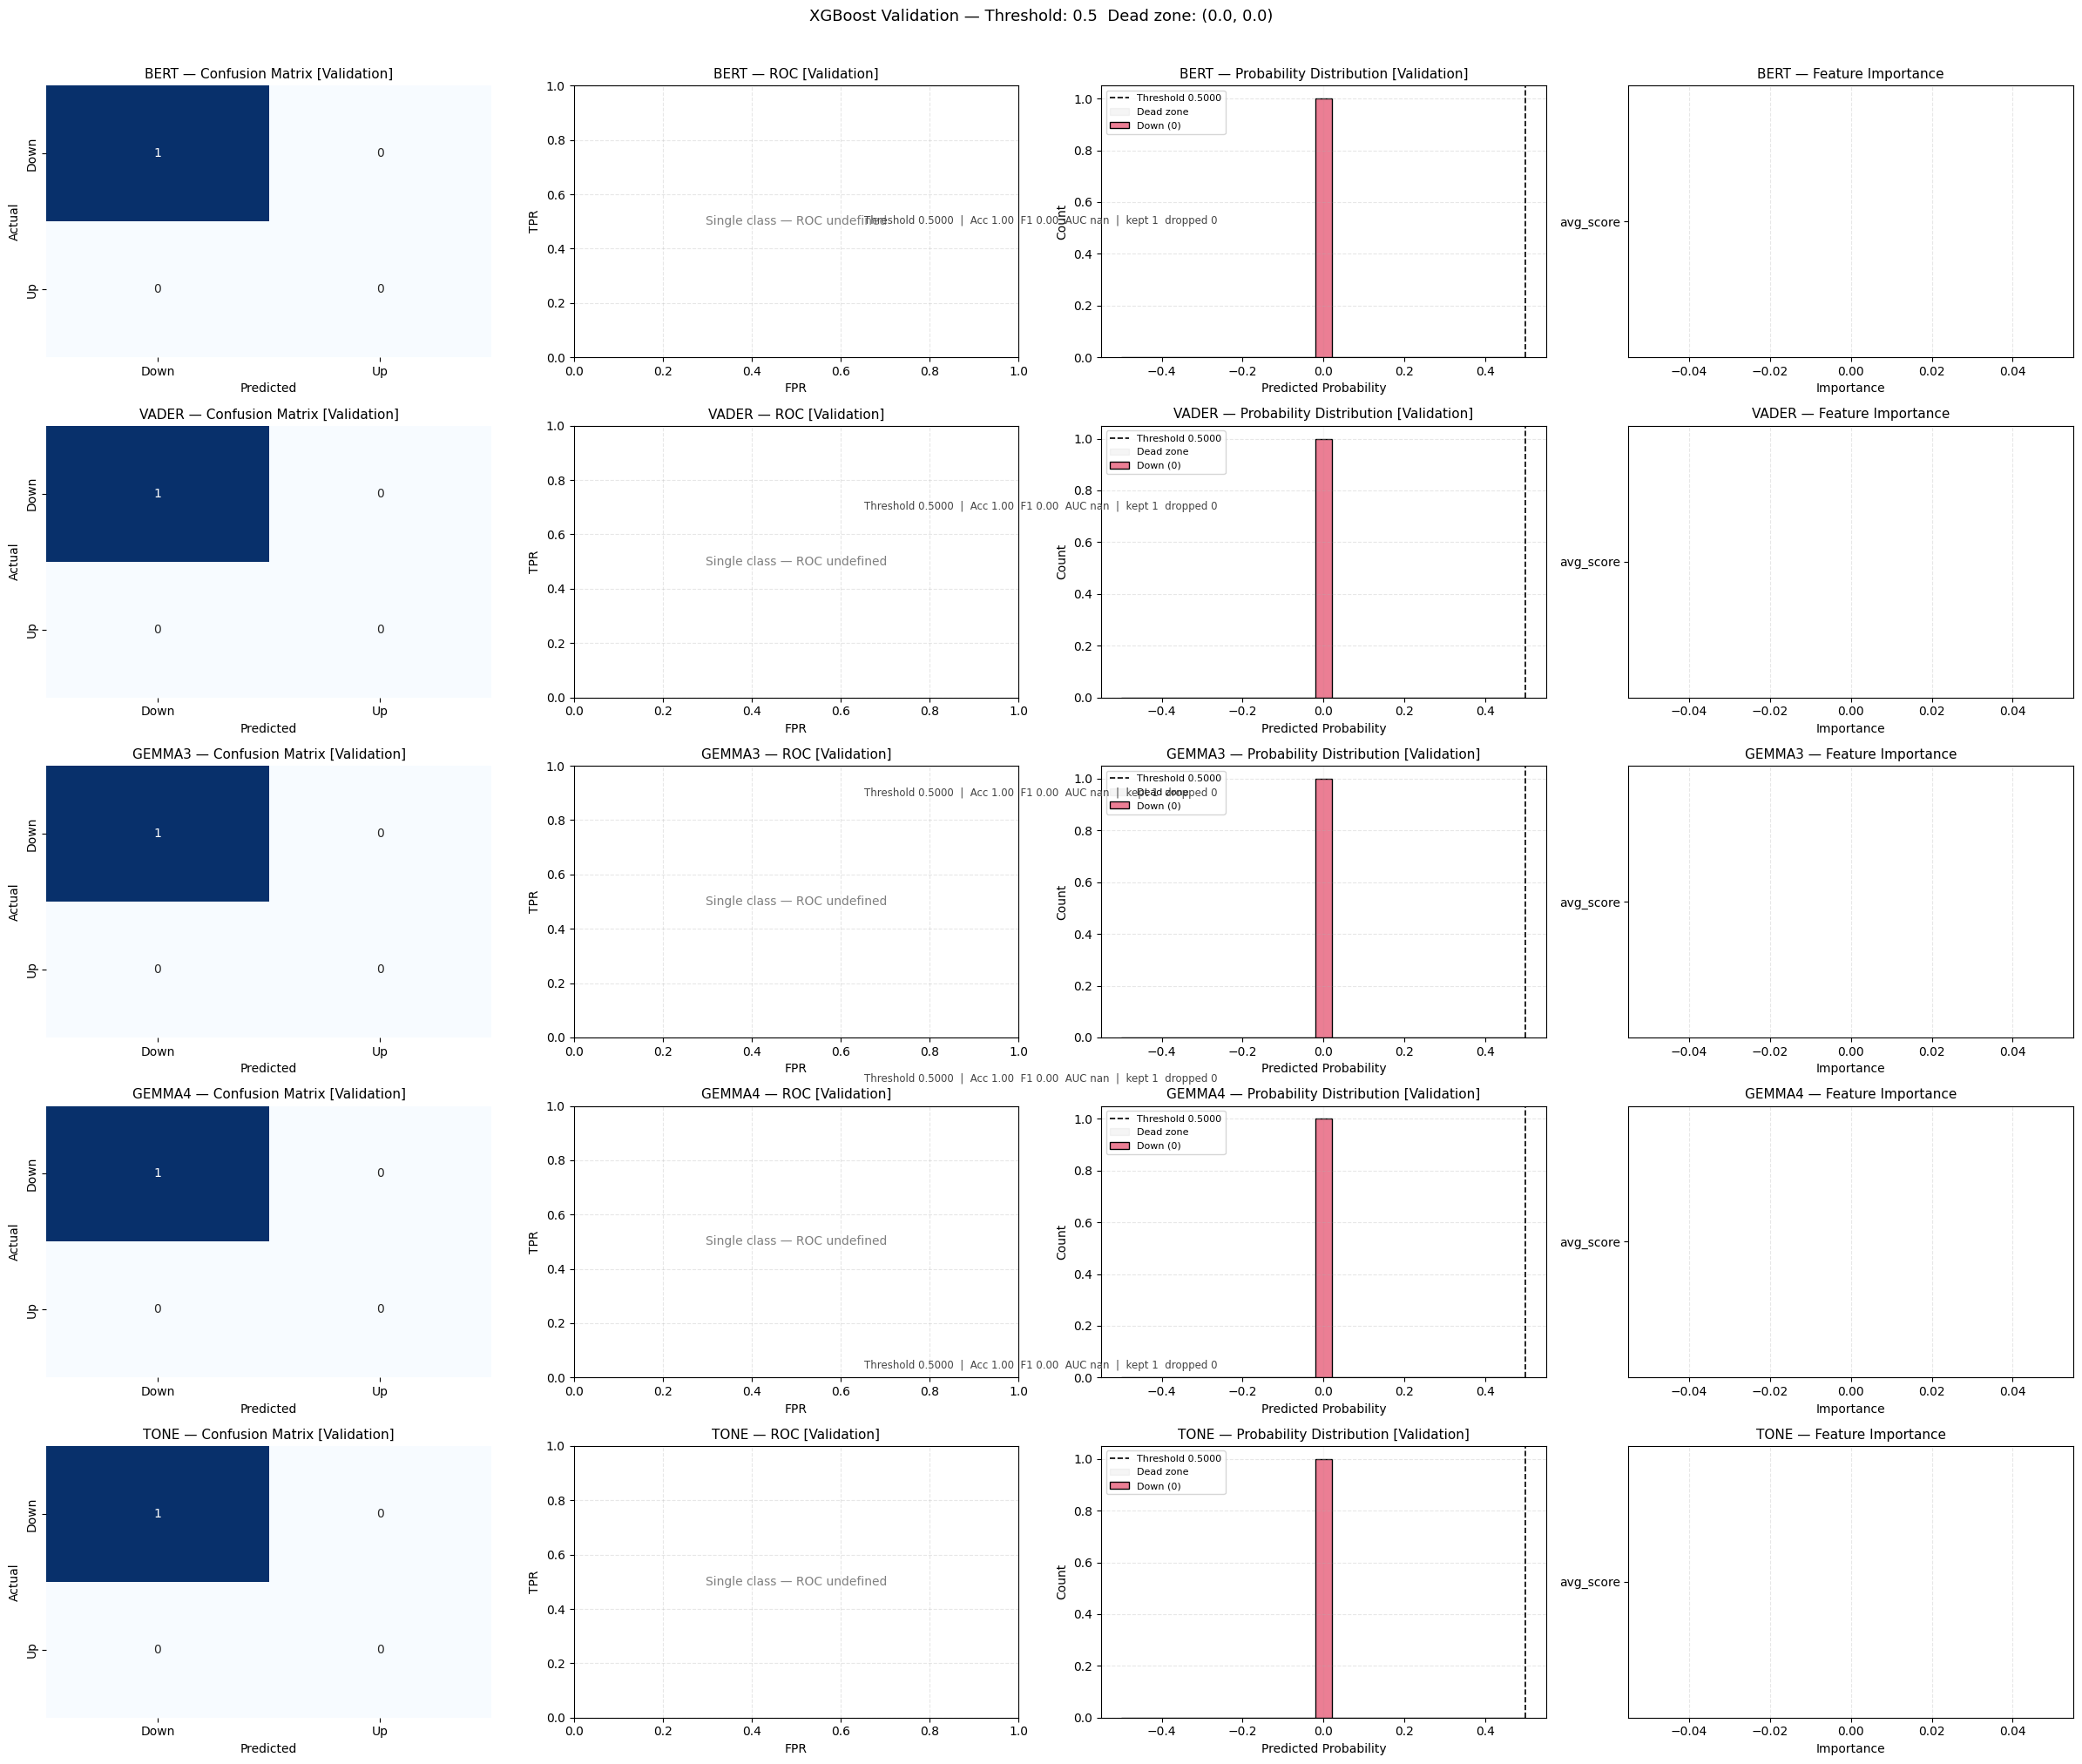

In [95]:
def plot_model_diagnostics(
    models_dict: dict,
    splits_dict: dict,
    thresholds: dict,
    features: list[str],
    target_col: str,
    split_key: int = 1,   # 0=train, 1=val, 2=test
    cmap: str = "Blues",
    color: str = "steelblue",
    title_suffix: str = "Validation",
) -> None:
    """4-panel diagnostic grid (confusion matrix, ROC, prob distribution, feature importance)."""
    model_names = list(models_dict.keys())
    n = len(model_names)
    fig, axes = plt.subplots(n, 4, figsize=(24, n * 4))
    fig.subplots_adjust(hspace=0.45, wspace=0.35)

    for row, name in enumerate(model_names):
        model     = models_dict[name]
        df_split  = splits_dict[name][split_key]
        threshold = thresholds.get(name, 0.5)

        X      = df_split[features]
        y_true_raw = df_split[target_col].astype(int).values

        y_prob_raw = model.predict_proba(X)[:, 1]
        y_prob, y_true, y_pred, n_kept, n_dropped = apply_dead_zone(
            y_prob_raw, y_true_raw, threshold, DZ_LOW, DZ_HIGH
        )

        ax_cm, ax_roc, ax_prob, ax_imp = axes[row]

        # Feature importance
        feat_df = (
            pd.DataFrame({"feature": features, "importance": model.feature_importances_})
            .sort_values("importance", ascending=True)
            .tail(12)
        )
        ax_imp.barh(feat_df["feature"], feat_df["importance"], color=color, alpha=0.75)
        ax_imp.set_title(f"{name.upper()} — Feature Importance", fontsize=11)
        ax_imp.set_xlabel("Importance")
        ax_imp.grid(axis="x", linestyle="--", alpha=0.3)

        if len(y_true) == 0:
            for ax, ttl in [(ax_cm, "Confusion Matrix"), (ax_roc, "ROC"), (ax_prob, "Probs")]:
                ax.set_title(f"{name.upper()} — {ttl}", fontsize=11)
                ax.text(0.5, 0.5, "No samples after dead-zone filter",
                        ha="center", va="center", color="gray", transform=ax.transAxes)
                ax.axis("off")
            continue

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax_cm,
                    xticklabels=["Down", "Up"], yticklabels=["Down", "Up"], cbar=False)
        ax_cm.set_title(f"{name.upper()} — Confusion Matrix [{title_suffix}]", fontsize=11)
        ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("Actual")

        # ROC
        if len(np.unique(y_true)) < 2:
            ax_roc.text(0.5, 0.5, "Single class — ROC undefined",
                        ha="center", va="center", color="gray", transform=ax_roc.transAxes)
        else:
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            ax_roc.plot(fpr, tpr, color=color, linewidth=2, label=f"AUC = {auc(fpr, tpr):.3f}")
            ax_roc.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
            ax_roc.legend(loc="lower right", fontsize=9)
        ax_roc.set_title(f"{name.upper()} — ROC [{title_suffix}]", fontsize=11)
        ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
        ax_roc.grid(linestyle="--", alpha=0.3)

        # Probability distribution
        for cls, lbl, c in [(0, "Down (0)", "crimson"), (1, "Up (1)", color)]:
            sub = y_prob[y_true == cls]
            if len(sub) > 0:
                sns.histplot(sub, bins=25, color=c, alpha=0.55, ax=ax_prob,
                             label=lbl, kde=len(sub) > 5)
        ax_prob.axvline(threshold, color="black", linestyle="--",
                        linewidth=1.2, label=f"Threshold {threshold:.4f}")
        ax_prob.axvspan(DZ_LOW, DZ_HIGH, alpha=0.08, color="gray", label="Dead zone")
        ax_prob.set_title(f"{name.upper()} — Probability Distribution [{title_suffix}]", fontsize=11)
        ax_prob.set_xlabel("Predicted Probability"); ax_prob.set_ylabel("Count")
        ax_prob.legend(fontsize=8)
        ax_prob.grid(axis="y", linestyle="--", alpha=0.3)

        # Row annotation
        metrics = metric_bundle(y_true, y_pred, y_prob)
        fig.text(
            0.5, axes[row, 0].get_position().y1 + 0.005,
            f"Threshold {threshold:.4f}  |  Acc {metrics['accuracy']:.2f}  "
            f"F1 {metrics['f1']:.2f}  AUC {metrics['roc_auc']:.2f}  |  "
            f"kept {n_kept}  dropped {n_dropped}",
            ha="center", va="bottom", fontsize=8.5, color="#444", transform=fig.transFigure,
        )

    thresh_label = "auto" if AUTO_THRESHOLD else str(DECISION_THRESHOLD)
    plt.suptitle(
        f"XGBoost {title_suffix} — Threshold: {thresh_label}  Dead zone: {THRESHOLD_DEAD_ZONE}",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.show()


plot_model_diagnostics(
    xgb_models, splits, best_thresholds,
    XGB_FEATURES, TARGET_COL,
    split_key=1, cmap="Blues", color="steelblue", title_suffix="Validation",
)

---
## 10 · Holdout Test Evaluation


HOLDOUT TEST — Threshold: 0.5  Dead zone: (0.0, 0.0)
Model          Acc    Prec     Rec      F1     AUC    Kept    Drop
-----------------------------------------------------------------
bert           nan     nan     nan     nan     nan       0       0
vader          nan     nan     nan     nan     nan       0       0
gemma3         nan     nan     nan     nan     nan       0       0
gemma4         nan     nan     nan     nan     nan       0       0
tone           nan     nan     nan     nan     nan       0       0


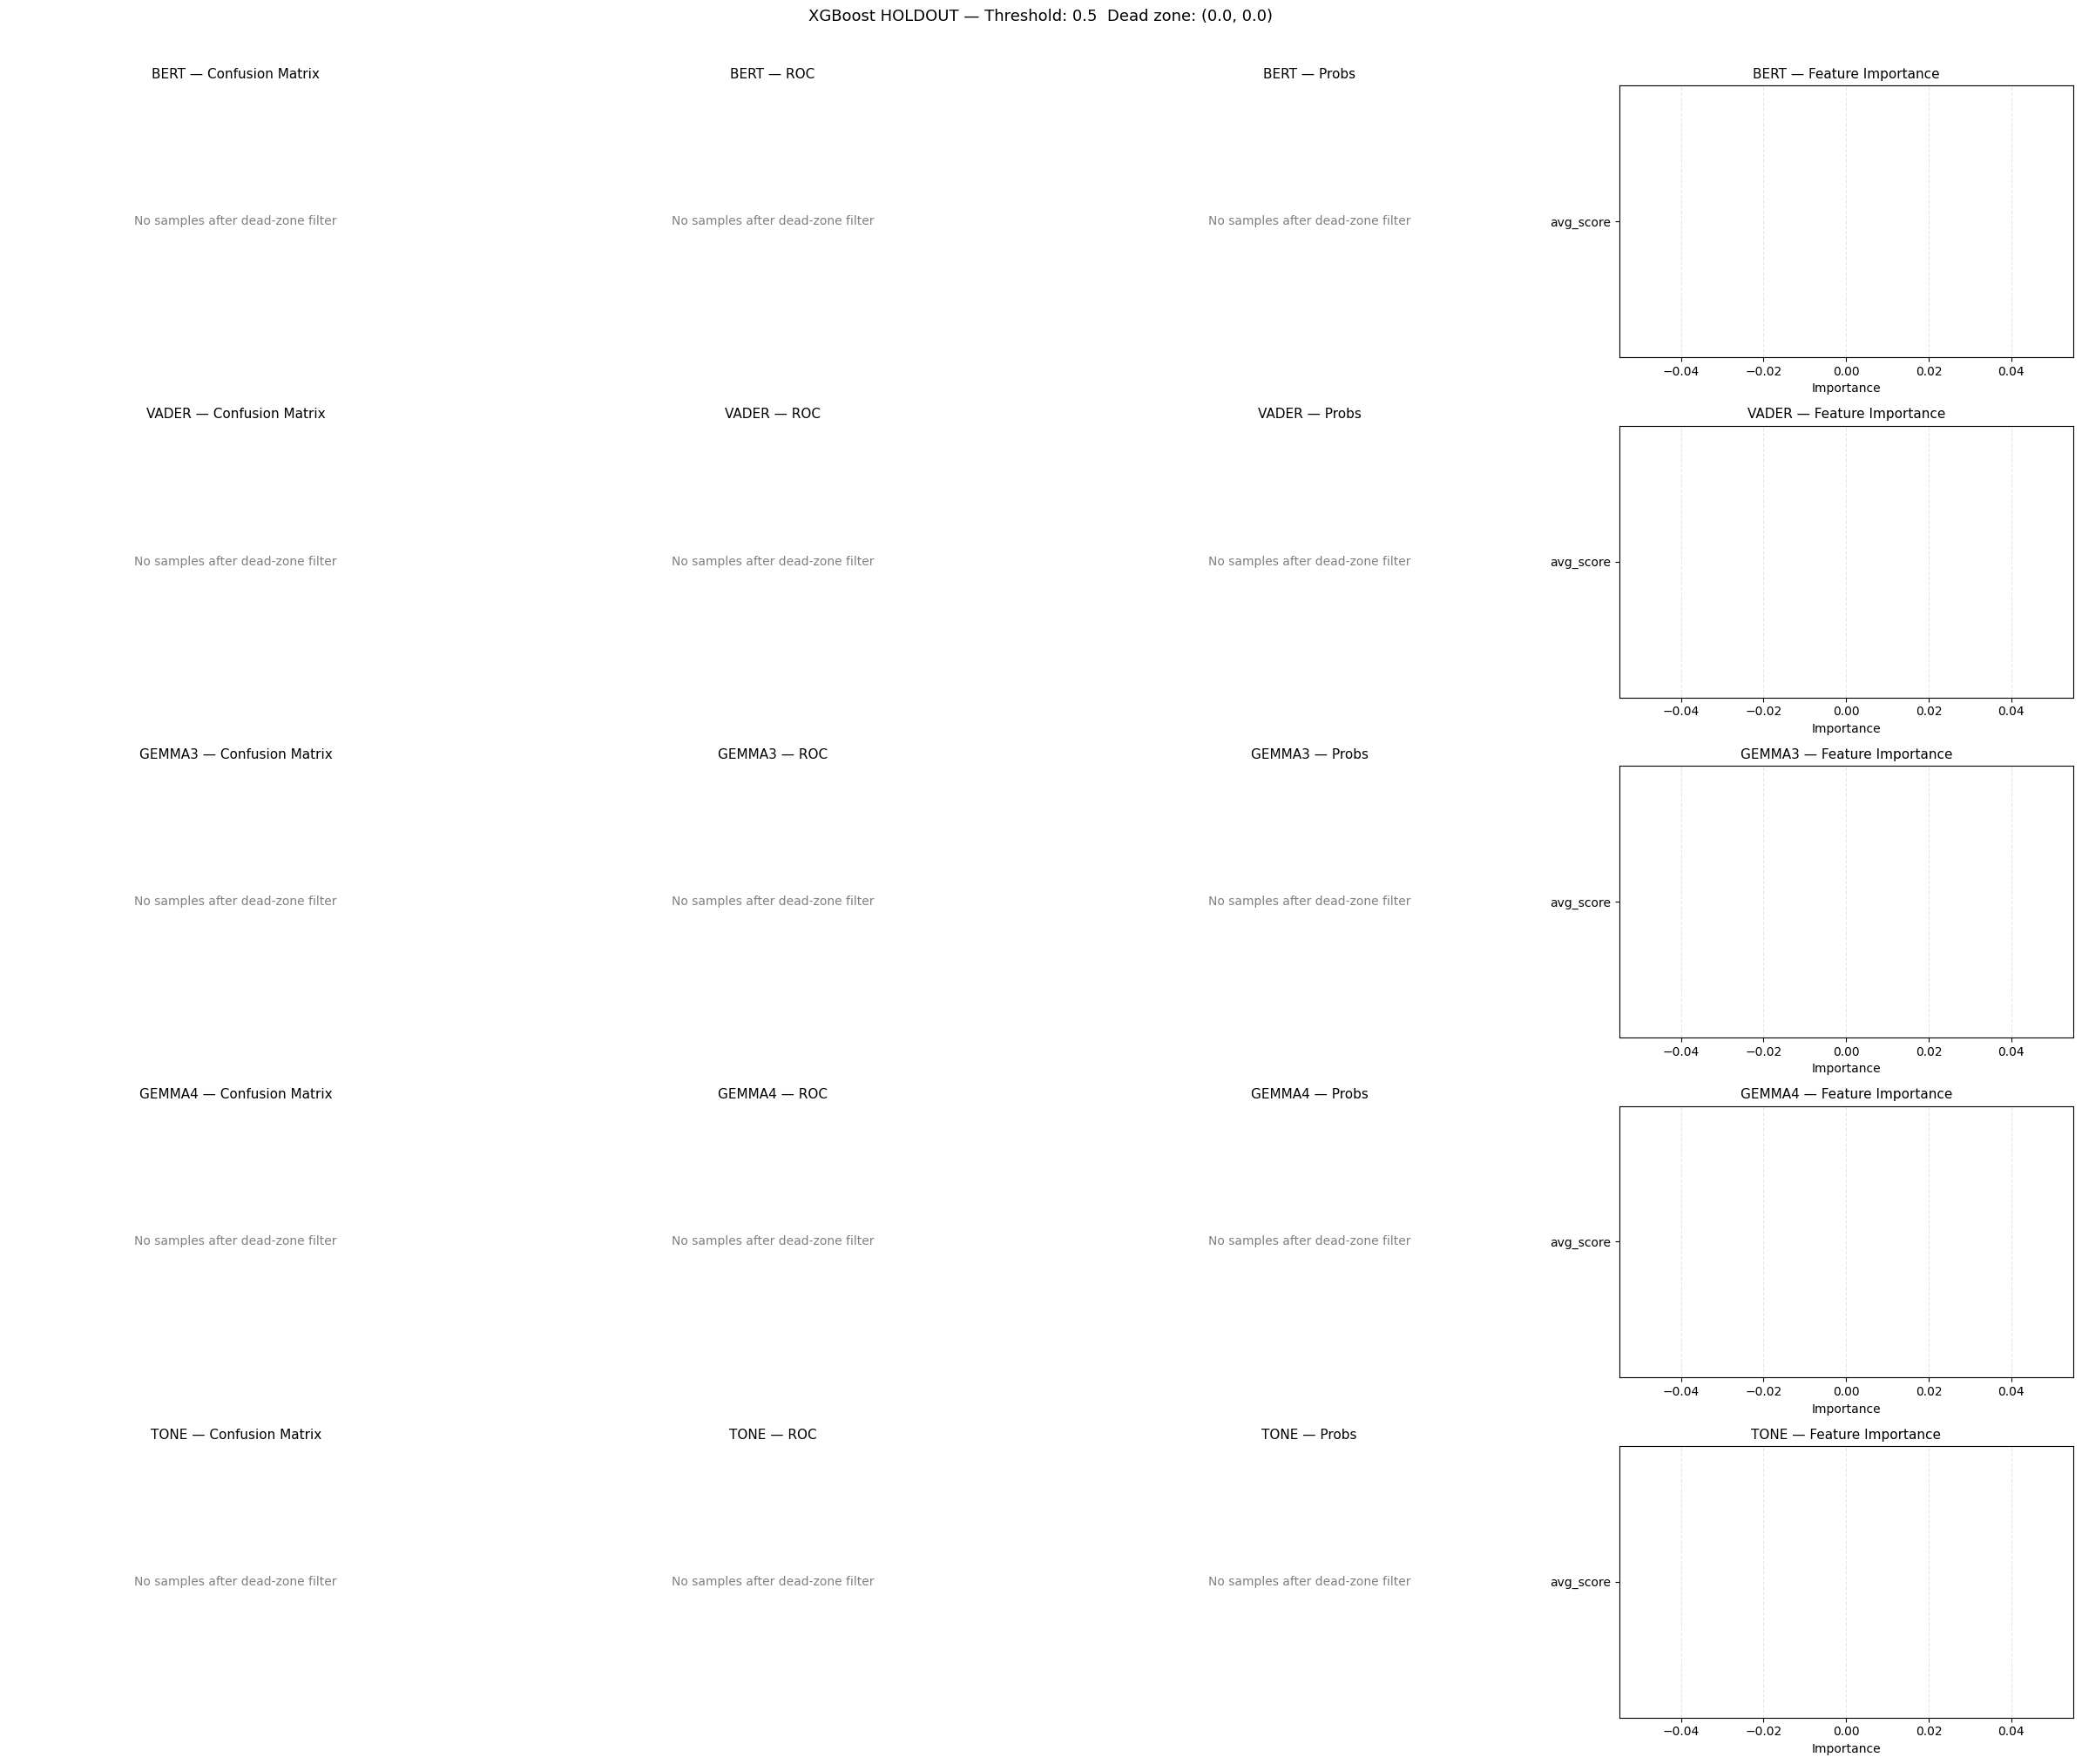

In [96]:
frozen_models = {name: joblib.load(os.path.join(SESSION_LOG_DIR, f"xgb_{name}_frozen.pkl")) for name in SENTIMENT_MODELS}

holdout_results = {}
for name in SENTIMENT_MODELS:
    _, _, df_test = splits[name]
    y_prob_raw = frozen_models[name].predict_proba(df_test[XGB_FEATURES])[:, 1]
    y_prob, y_true, y_pred, n_kept, n_dropped = apply_dead_zone(
        y_prob_raw, df_test[TARGET_COL].astype(int).values,
        float(DECISION_THRESHOLD), DZ_LOW, DZ_HIGH,
    )
    holdout_results[name] = dict(
        y_prob=y_prob, y_true=y_true, y_pred=y_pred,
        n_kept=n_kept, n_dropped=n_dropped,
        metrics=metric_bundle(y_true, y_pred, y_prob),
    )

# Summary table
print(f"\n{'='*65}")
print(f"HOLDOUT TEST — Threshold: {DECISION_THRESHOLD}  Dead zone: {THRESHOLD_DEAD_ZONE}")
print(f"{'='*65}")
print(f"{'Model':<10} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'Kept':>7} {'Drop':>7}")
print("-" * 65)
for name, res in holdout_results.items():
    m = res["metrics"]
    print(f"{name:<10} {m['accuracy']:>7.3f} {m['precision']:>7.3f} "
          f"{m['recall']:>7.3f} {m['f1']:>7.3f} {m['roc_auc']:>7.3f} "
          f"{res['n_kept']:>7} {res['n_dropped']:>7}")

plot_model_diagnostics(
    frozen_models, splits, {n: float(DECISION_THRESHOLD) for n in SENTIMENT_MODELS},
    XGB_FEATURES, TARGET_COL,
    split_key=2, cmap="Oranges", color="darkorange", title_suffix="HOLDOUT",
)

---
## 11 · Trading Simulation

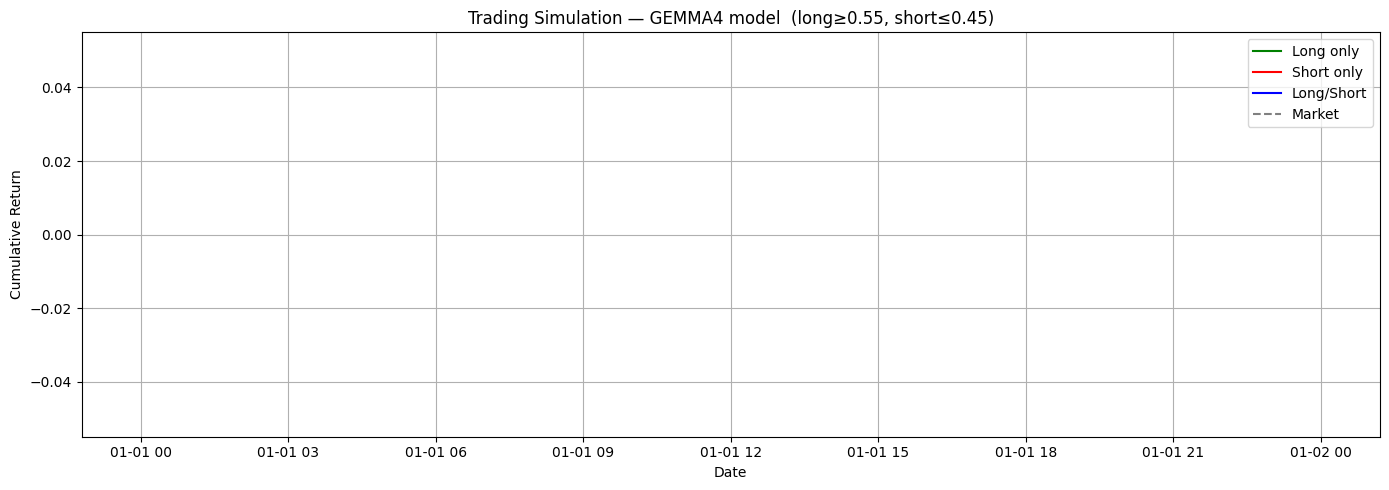

In [92]:
def simulate_trading(
    model,
    df_test: pd.DataFrame,
    df_prices_full: pd.DataFrame,
    features: list[str],
    long_thresh: float = LONG_THRESHOLD,
    short_thresh: float = SHORT_THRESHOLD,
) -> pd.DataFrame:
    """
    Simulate long-only, short-only, and long/short strategies.

    Returns a DataFrame with cumulative return columns:
    cum_long, cum_short, cum_ls, cum_market.
    """
    sim = df_test.merge(df_prices_full[["date", "return"]], on="date", how="left").copy()
    sim["y_prob"] = model.predict_proba(sim[features])[:, 1]

    sim["signal_long"]  = (sim["y_prob"] >= long_thresh).astype(int)
    sim["signal_short"] = -(sim["y_prob"] <= short_thresh).astype(int)
    sim["signal_ls"]    = sim["signal_long"] + sim["signal_short"]

    for col, sig in [("cum_long", "signal_long"), ("cum_short", "signal_short"), ("cum_ls", "signal_ls")]:
        sim[col] = (1 + sim[sig] * sim["return"]).cumprod()
    sim["cum_market"] = (1 + sim["return"]).cumprod()

    return sim


def plot_trading_simulation(sim: pd.DataFrame, title: str = "") -> None:
    plt.figure(figsize=(14, 5))
    for col, lbl, c in [
        ("cum_long",   "Long only",   "green"),
        ("cum_short",  "Short only",  "red"),
        ("cum_ls",     "Long/Short",  "blue"),
        ("cum_market", "Market",      "gray"),
    ]:
        plt.plot(sim["date"], sim[col], label=lbl, color=c,
                 linestyle="--" if c == "gray" else "-")
    plt.title(title or "Trading Simulation")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Use the best single-model (gemma4 preferred) for the simulation
sim_model_name = "gemma4" if "gemma4" in frozen_models else SENTIMENT_MODELS[0]
_, _, df_test_sim_src = splits[sim_model_name]

sim = simulate_trading(
    frozen_models[sim_model_name],
    df_test_sim_src,
    df_prices,
    XGB_FEATURES,
)

plot_trading_simulation(
    sim,
    title=f"Trading Simulation — {sim_model_name.upper()} model  "
          f"(long≥{LONG_THRESHOLD}, short≤{SHORT_THRESHOLD})",
)

---
## 12 · Backup & Restore

In [ ]:
from datetime import datetime as _dt

def backup_session(
    backup_root: str = BACKUP_ROOT,
    extra_model_vars: list[str] | None = None,
    validation_results: dict = None,
) -> str:
    """
    Snapshot all DataFrames and model dicts currently in memory.

    Returns the path of the timestamped backup directory.
    """
    # Find top model by accuracy
    if validation_results:
        top_model = max(validation_results.items(), key=lambda x: x[1]['val_metrics'].get('accuracy', 0))
        top_name = top_model[0].upper()
        top_acc = int(round(top_model[1]['val_metrics'].get('accuracy', 0) * 100))
    else:
        top_name = "NA"
        top_acc = 0

    ts = _dt.now().strftime("%Y%m%d_%H%M")
    backup_dir = os.path.join(backup_root, f"backup_{ts}__{top_name}_{top_acc}")
    os.makedirs(backup_dir, exist_ok=True)

    # DataFrames
    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame):
            path = os.path.join(backup_dir, f"{name}.parquet")
            obj.to_parquet(path)
            print(f"  DataFrame: {name} → {path}")

    # Model dicts
    model_var_names = ["xgb_models", "frozen_models"] + (extra_model_vars or [])
    for var_name in model_var_names:
        obj = globals().get(var_name)
        if obj is not None:
            path = os.path.join(backup_dir, f"{var_name}.joblib")
            joblib.dump(obj, path)
            print(f"  Models   : {var_name} → {path}")

    # Save summary statistics as text file
    if validation_results:
        summary_path = os.path.join(backup_dir, "_.0_model_summary.txt")
        with open(summary_path, "w") as f:
            f.write(f"{'Model':<10} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'Kept':>7} {'Drop':>7}\n")
            f.write("-" * 65 + "\n")
            for name, res in validation_results.items():
                m = res["val_metrics"]
                f.write(
                    f"{name:<10} {m['accuracy']:>7.3f} {m['precision']:>7.3f} "
                    f"{m['recall']:>7.3f} {m['f1']:>7.3f} {m['roc_auc']:>7.3f} "
                    f"{res['rows_kept']:>7} {res['rows_dropped']:>7}\n"
                )
        print(f"  Summary  : model_summary.txt → {summary_path}")

    print(f"\nBackup complete: {backup_dir}")
    return backup_dir

def restore_session(backup_dir: str):
    """
    Restore DataFrames and model dicts from a backup directory.
    """
    import glob

    # Restore DataFrames
    for parquet_file in glob.glob(os.path.join(backup_dir, "*.parquet")):
        var_name = os.path.splitext(os.path.basename(parquet_file))[0]
        try:
            globals()[var_name] = pd.read_parquet(parquet_file)
            print(f"  Restored DataFrame: {var_name} ← {parquet_file}")
        except Exception as e:
            print(f"  Failed to restore DataFrame {var_name}: {e}")

    # Restore model dicts
    for joblib_file in glob.glob(os.path.join(backup_dir, "*.joblib")):
        var_name = os.path.splitext(os.path.basename(joblib_file))[0]
        try:
            globals()[var_name] = joblib.load(joblib_file)
            print(f"  Restored model dict: {var_name} ← {joblib_file}")
        except Exception as e:
            print(f"  Failed to restore model dict {var_name}: {e}")

    print(f"\nRestore complete from: {backup_dir}")

# Example usage:
backup_dir = backup_session(validation_results=validation_results)
#restore_session(r"D:\PRODStockNews\backup\backup_20260415_1739__BERT_100")

  Restored DataFrame: articles_per_day ← D:\PRODStockNews\backup\backup_20260415_1739__BERT_100\articles_per_day.parquet
  Restored DataFrame: df ← D:\PRODStockNews\backup\backup_20260415_1739__BERT_100\df.parquet
  Restored DataFrame: df_avg_sentiment ← D:\PRODStockNews\backup\backup_20260415_1739__BERT_100\df_avg_sentiment.parquet
  Restored DataFrame: df_m ← D:\PRODStockNews\backup\backup_20260415_1739__BERT_100\df_m.parquet
  Restored DataFrame: df_merged ← D:\PRODStockNews\backup\backup_20260415_1739__BERT_100\df_merged.parquet
  Restored DataFrame: df_merged_bert ← D:\PRODStockNews\backup\backup_20260415_1739__BERT_100\df_merged_bert.parquet
  Restored DataFrame: df_merged_gemma3 ← D:\PRODStockNews\backup\backup_20260415_1739__BERT_100\df_merged_gemma3.parquet
  Restored DataFrame: df_merged_gemma4 ← D:\PRODStockNews\backup\backup_20260415_1739__BERT_100\df_merged_gemma4.parquet
  Restored DataFrame: df_merged_tone ← D:\PRODStockNews\backup\backup_20260415_1739__BERT_100\df_merge